Total samples loaded: 3960
Valid samples extracted: 0
No valid pose data found. Creating test dataset.
   feature1  feature2  label
0  0.748368  0.137434      0
1  0.127778  0.857743      0
2  0.079642  0.934390      1
3  0.067969  0.145425      0
4  0.794617  0.320427      1
CSV saved: C:\Users\23adsb49\Downloads\archive\evaluation_scale.json
Training samples: 200


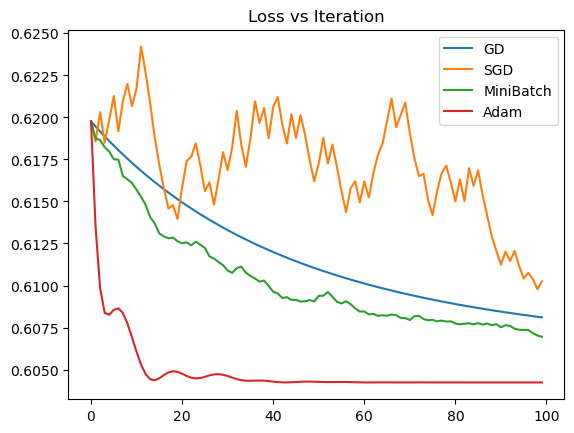

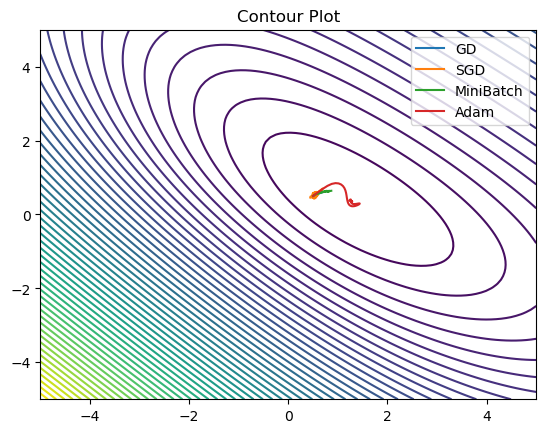

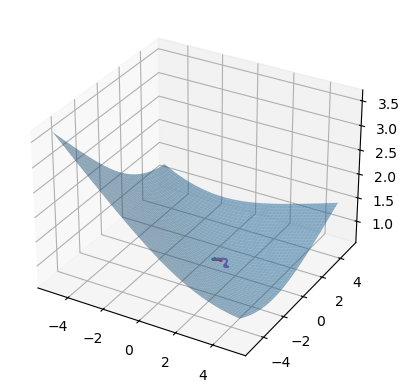

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


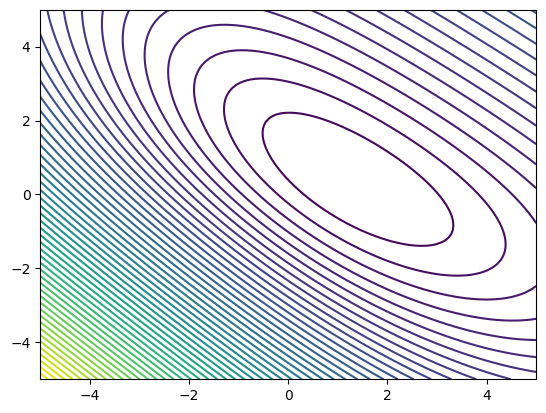

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
json_path = r"C:\Users\23adsb49\Downloads\archive\evaluation_scale.json"
with open(json_path, "r") as f:
    pose_data = json.load(f)
print("Total samples loaded:", len(pose_data))
feature1 = []
feature2 = []
labels = []
def safe_extract(sample):
    arr = np.array(sample).flatten()
    if len(arr) < 4:
        return None
    x1, y1 = arr[0], arr[1]
    x2, y2 = arr[2], arr[3]
    shoulder_dist = np.sqrt((x1-x2)**2 + (y1-y2)**2)
    if shoulder_dist == 0:
        return None
    f1 = abs(x1-y1)/(shoulder_dist+1e-8)
    f2 = abs(x2-y2)/(shoulder_dist+1e-8)
    return f1, f2
for i, sample in enumerate(pose_data):
    result = safe_extract(sample)
    if result is None:
       continue
    f1, f2 = result
    feature1.append(f1)
    feature2.append(f2)
    if i < len(pose_data)//2:
        labels.append(1)
    else:
        labels.append(0)
print("Valid samples extracted:", len(feature1))
if len(feature1) == 0:

    print("No valid pose data found. Creating test dataset.")

    feature1 = np.random.rand(200)
    feature2 = np.random.rand(200)
    labels = (feature1+feature2>1).astype(int)
data = pd.DataFrame({
    "feature1": feature1,
    "feature2": feature2,
    "label": labels
})
print(data.head())
csv_path = r"C:\Users\23adsb49\Downloads\archive\evaluation_scale.json"
data.to_csv(csv_path,index=False)
print("CSV saved:", csv_path)
X = data[["feature1","feature2"]].values.astype(float)
y = data["label"].values.astype(float)
n_samples = len(y)
print("Training samples:", n_samples)
def sigmoid(z):
    return 1/(1+np.exp(-z))
def loss_function(w):
    z = X.dot(w)
    y_pred = sigmoid(z)
    return -np.mean(
        y*np.log(y_pred+1e-8) +
        (1-y)*np.log(1-y_pred+1e-8)
    )
def gradient(w):

    z = X.dot(w)
    y_pred = sigmoid(z)

    return X.T.dot(y_pred-y)/n_samples
def gradient_descent(w_init,lr=0.1,iterations=100):

    w=w_init.copy().astype(float)
    path=[]
    losses=[]

    for i in range(iterations):

        path.append(w.copy())
        losses.append(loss_function(w))

        w=w-lr*gradient(w)
    return np.array(path),np.array(losses)
def sgd(w_init,lr=0.1,iterations=100):
    w=w_init.copy().astype(float)
    path=[]
    losses=[]
    for i in range(iterations):
        path.append(w.copy())
        losses.append(loss_function(w))
        idx=np.random.randint(n_samples)
        xi=X[idx]
        yi=y[idx]
        grad=xi*(sigmoid(xi.dot(w))-yi)
        w=w-lr*grad
    return np.array(path),np.array(losses)
def minibatch(w_init,lr=0.1,batch=16,iterations=100):
    w=w_init.copy().astype(float)
    path=[]
    losses=[]
    for i in range(iterations):
      path.append(w.copy())
        losses.append(loss_function(w))
        idx=np.random.choice(n_samples,batch)
        xb=X[idx]
        yb=y[idx]
        grad=xb.T.dot(sigmoid(xb.dot(w))-yb)/batch
        w=w-lr*grad
    return np.array(path),np.array(losses)
def adam(w_init,lr=0.1,iterations=100):
    w=w_init.copy().astype(float)
    m=np.zeros_like(w)
    v=np.zeros_like(w)
    path=[]
    losses=[]
    for t in range(1,iterations+1):
        path.append(w.copy())
        losses.append(loss_function(w))
        grad=gradient(w)
        m=0.9*m+0.1*grad
        v=0.999*v+0.001*(grad**2)
        mhat=m/(1-0.9**t)
        vhat=v/(1-0.999**t)
        w=w-lr*mhat/(np.sqrt(vhat)+1e-8)
    return np.array(path),np.array(losses)
w_init=np.array([0.5,0.5])
paths={}
losses={}
paths["GD"],losses["GD"]=gradient_descent(w_init)
paths["SGD"],losses["SGD"]=sgd(w_init)
paths["MiniBatch"],losses["MiniBatch"]=minibatch(w_init)
paths["Adam"],losses["Adam"]=adam(w_init)
plt.figure()
for name in losses:
    plt.plot(losses[name],label=name)
plt.legend()
plt.title("Loss vs Iteration")
plt.show()
w1=np.linspace(-5,5,100)
w2=np.linspace(-5,5,100)
W1,W2=np.meshgrid(w1,w2)
Z=np.zeros_like(W1)
for i in range(100):
    for j in range(100):
        Z[i,j]=loss_function(np.array([W1[i,j],W2[i,j]]))
plt.figure()
plt.contour(W1,W2,Z,50)
for name in paths:
    plt.plot(paths[name][:,0],paths[name][:,1],label=name)
plt.legend()
plt.title("Contour Plot")
plt.show()
fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")
ax.plot_surface(W1,W2,Z,alpha=0.5)
for name in paths:
    z=[loss_function(p) for p in paths[name]]
    ax.plot(paths[name][:,0],paths[name][:,1],z)
plt.show()
fig,ax=plt.subplots()
ax.contour(W1,W2,Z,50)
lines={}
for name in paths:
    line,=ax.plot([],[])
    lines[name]=line
def update(frame):
    for name in paths:
        lines[name].set_data(
            paths[name][:frame,0],
            paths[name][:frame,1]
        )
    return lines.values()
anim=FuncAnimation(fig,update,frames=100,interval=100)
plt.show()


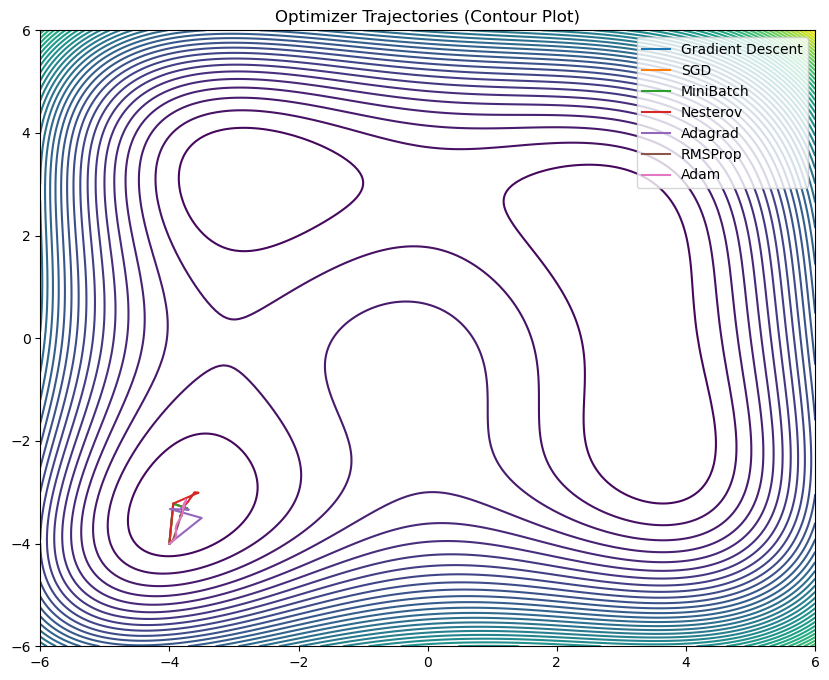

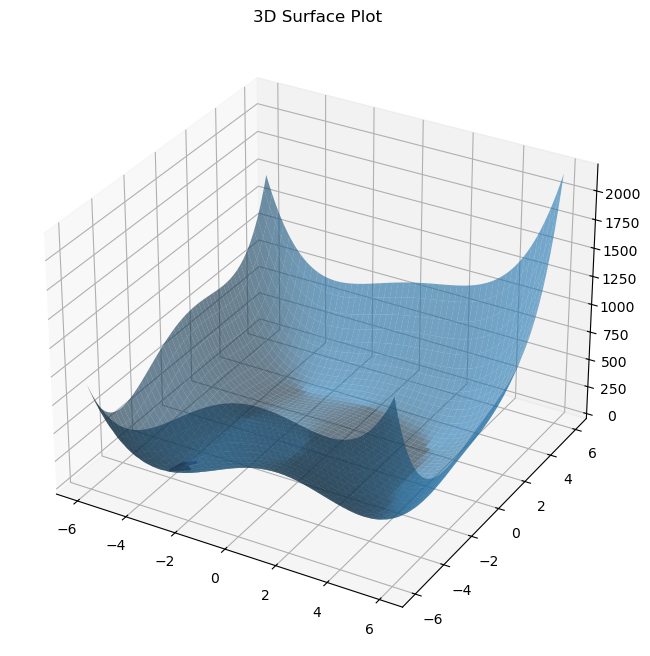

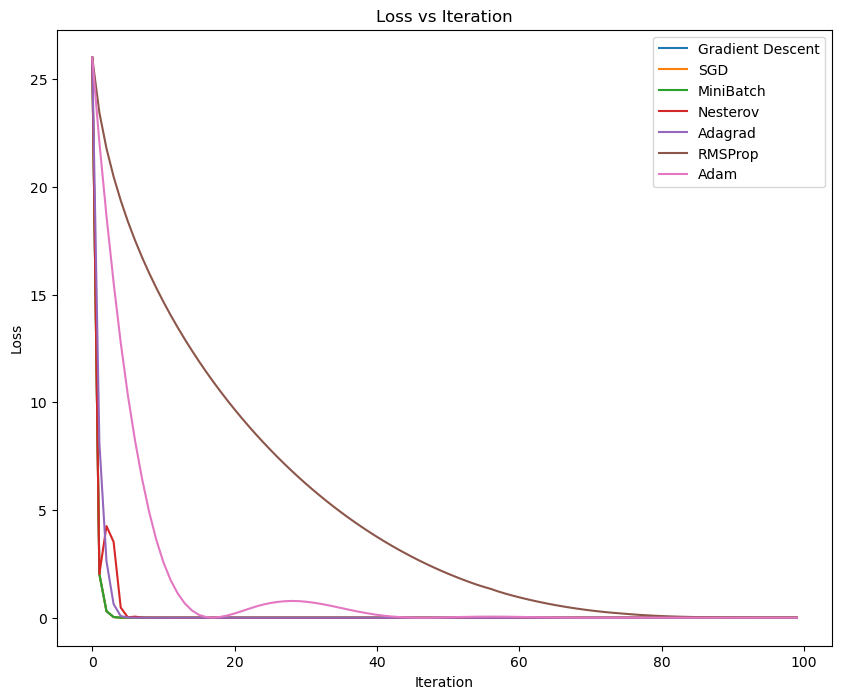

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


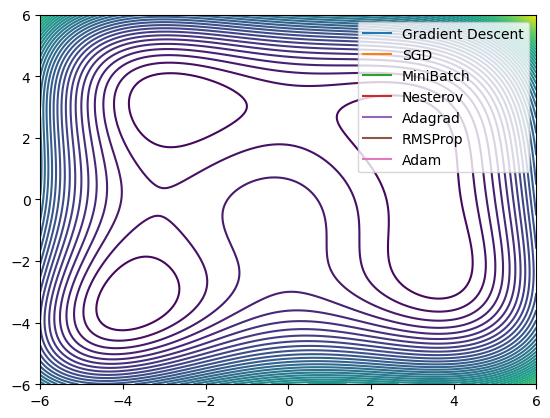

In [13]:
# ============================================
# LAB EXPERIMENT – OPTIMIZER VISUALIZATION
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

# ============================================
# OBJECTIVE FUNCTION (Himmelblau Function)
# ============================================

def loss_function(w):
    w1, w2 = w[0], w[1]
    return (w1**2 + w2 - 11)**2 + (w1 + w2**2 - 7)**2


def gradient(w):
    w1, w2 = w[0], w[1]

    dw1 = 4*w1*(w1**2 + w2 - 11) + 2*(w1 + w2**2 - 7)
    dw2 = 2*(w1**2 + w2 - 11) + 4*w2*(w1 + w2**2 - 7)

    return np.array([dw1, dw2], dtype=float)


# ============================================
# OPTIMIZERS
# ============================================

def gradient_descent(w_init, lr=0.01, iterations=100):
    w = w_init.astype(float).copy()

    path = []
    losses = []

    for i in range(iterations):
        path.append(w.copy())
        losses.append(loss_function(w))

        grad = gradient(w)
        w = w - lr * grad

    return np.array(path), np.array(losses)


def sgd(w_init, lr=0.01, iterations=100):

    w = w_init.astype(float).copy()
    path, losses = [], []

    for i in range(iterations):

        path.append(w.copy())
        losses.append(loss_function(w))

        grad = gradient(w)

        noise = np.random.normal(0, 0.1, 2)
        grad = grad + noise

        w = w - lr * grad

    return np.array(path), np.array(losses)


def minibatch_gd(w_init, lr=0.01, iterations=100):

    w = w_init.astype(float).copy()
    path, losses = [], []

    for i in range(iterations):

        path.append(w.copy())
        losses.append(loss_function(w))

        grad = gradient(w)
        noise = np.random.normal(0, 0.05, 2)

        w = w - lr * (grad + noise)

    return np.array(path), np.array(losses)


def nesterov(w_init, lr=0.01, gamma=0.9, iterations=100):

    w = w_init.astype(float).copy()
    v = np.zeros_like(w)

    path, losses = [], []

    for i in range(iterations):

        path.append(w.copy())
        losses.append(loss_function(w))

        lookahead = w - gamma * v
        grad = gradient(lookahead)

        v = gamma * v + lr * grad
        w = w - v

    return np.array(path), np.array(losses)


def adagrad(w_init, lr=0.5, iterations=100):

    w = w_init.astype(float).copy()
    G = np.zeros_like(w, dtype=float)

    path, losses = [], []

    for i in range(iterations):

        path.append(w.copy())
        losses.append(loss_function(w))

        grad = gradient(w)

        G += grad**2

        w = w - lr * grad / (np.sqrt(G) + 1e-8)

    return np.array(path), np.array(losses)


def rmsprop(w_init, lr=0.01, beta=0.9, iterations=100):

    w = w_init.astype(float).copy()
    Eg = np.zeros_like(w, dtype=float)

    path, losses = [], []

    for i in range(iterations):

        path.append(w.copy())
        losses.append(loss_function(w))

        grad = gradient(w)

        Eg = beta*Eg + (1-beta)*(grad**2)

        w = w - lr*grad/(np.sqrt(Eg)+1e-8)

    return np.array(path), np.array(losses)


def adam(w_init, lr=0.05, beta1=0.9, beta2=0.999, iterations=100):

    w = w_init.astype(float).copy()

    m = np.zeros_like(w)
    v = np.zeros_like(w)

    path, losses = [], []

    for t in range(1, iterations+1):

        path.append(w.copy())
        losses.append(loss_function(w))

        grad = gradient(w)

        m = beta1*m + (1-beta1)*grad
        v = beta2*v + (1-beta2)*(grad**2)

        m_hat = m/(1-beta1**t)
        v_hat = v/(1-beta2**t)

        w = w - lr*m_hat/(np.sqrt(v_hat)+1e-8)

    return np.array(path), np.array(losses)


# ============================================
# RUN ALL OPTIMIZERS
# ============================================

w_init = np.array([-4.0, -4.0])

paths = {}
losses = {}

paths["Gradient Descent"], losses["Gradient Descent"] = gradient_descent(w_init)
paths["SGD"], losses["SGD"] = sgd(w_init)
paths["MiniBatch"], losses["MiniBatch"] = minibatch_gd(w_init)
paths["Nesterov"], losses["Nesterov"] = nesterov(w_init)
paths["Adagrad"], losses["Adagrad"] = adagrad(w_init)
paths["RMSProp"], losses["RMSProp"] = rmsprop(w_init)
paths["Adam"], losses["Adam"] = adam(w_init)


# ============================================
# CREATE CONTOUR DATA
# ============================================

x = np.linspace(-6, 6, 200)
y = np.linspace(-6, 6, 200)

X, Y = np.meshgrid(x, y)

Z = (X**2 + Y - 11)**2 + (X + Y**2 - 7)**2


# ============================================
# 2D CONTOUR PLOT
# ============================================

plt.figure(figsize=(10,8))

plt.contour(X, Y, Z, levels=50)

for name, path in paths.items():
    plt.plot(path[:,0], path[:,1], label=name)

plt.legend()
plt.title("Optimizer Trajectories (Contour Plot)")
plt.show()


# ============================================
# 3D SURFACE PLOT
# ============================================

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, alpha=0.6)

for name, path in paths.items():
    z_path = [loss_function(p) for p in path]
    ax.plot(path[:,0], path[:,1], z_path)

plt.title("3D Surface Plot")
plt.show()


# ============================================
# LOSS VS ITERATION
# ============================================

plt.figure(figsize=(10,8))

for name, loss in losses.items():
    plt.plot(loss, label=name)

plt.legend()
plt.title("Loss vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()


# ============================================
# ANIMATED CONTOUR
# ============================================

fig, ax = plt.subplots()

ax.contour(X, Y, Z, levels=50)

lines = {}

for name in paths:
    line, = ax.plot([], [], label=name)
    lines[name] = line

ax.legend()

def update(frame):

    for name, path in paths.items():
        lines[name].set_data(path[:frame,0], path[:frame,1])

    return list(lines.values())

anim = FuncAnimation(fig, update, frames=100, interval=100)

plt.show()
